Import + get data initially ready for training + unlearning pipeline

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 

def rename_german_credit_columns(df):
    column_mapping = {
        "Attribute1": "Status_of_existing_checking_account",
        "Attribute2": "Duration_in_month",
        "Attribute3": "Credit_history",
        "Attribute4": "Purpose",
        "Attribute5": "Credit_amount",
        "Attribute6": "Savings_account_bonds",
        "Attribute7": "Present_employment_since",
        "Attribute8": "Installment_rate_in_percentage_of_disposable_income",
        "Attribute9": "Personal_status_and_sex",
        "Attribute10": "Other_debtors_guarantors",
        "Attribute11": "Present_residence_since",
        "Attribute12": "Property",
        "Attribute13": "Age_in_years",
        "Attribute14": "Other_installment_plans",
        "Attribute15": "Housing",
        "Attribute16": "Number_of_existing_credits_at_this_bank",
        "Attribute17": "Job",
        "Attribute18": "Number_of_people_being_liable_to_provide_maintenance_for",
        "Attribute19": "Telephone",
        "Attribute20": "Foreign_worker"
    }

    return df.rename(columns=column_mapping)

df = rename_german_credit_columns(X)

categorical_cols = [
        "Status_of_existing_checking_account",
        "Credit_history",
        "Purpose",
        "Savings_account_bonds",
        "Present_employment_since",
        "Personal_status_and_sex",
        "Other_debtors_guarantors",
        "Property",
        "Other_installment_plans",
        "Housing",
        "Job",
        "Telephone",
        "Foreign_worker"
    ]

df_encoded = pd.get_dummies(
        df,
        columns=categorical_cols
)

y['class'] = (y['class'] - 1).astype(float)


/tmp/ipykernel_3435696/1060118214.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['class'] = (y['class'] - 1).astype(float)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd.forward_ad as fwAD
from torch.func import functional_call
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.metrics import accuracy_score

--- Phase 1: Splitting Data & Applying Dual Scalers ---

--- Phase 2: Training Original Model ---
Epoch  20/1000 | Loss: 0.5840 | Accuracy: 71.1%
Epoch  40/1000 | Loss: 0.5610 | Accuracy: 71.4%
Epoch  60/1000 | Loss: 0.5480 | Accuracy: 71.9%
Epoch  80/1000 | Loss: 0.5380 | Accuracy: 72.2%
Epoch 100/1000 | Loss: 0.5300 | Accuracy: 72.5%
Epoch 120/1000 | Loss: 0.5234 | Accuracy: 73.3%
Epoch 140/1000 | Loss: 0.5177 | Accuracy: 73.4%
Epoch 160/1000 | Loss: 0.5129 | Accuracy: 73.5%
Epoch 180/1000 | Loss: 0.5087 | Accuracy: 74.0%
Epoch 200/1000 | Loss: 0.5051 | Accuracy: 74.4%
Epoch 220/1000 | Loss: 0.5018 | Accuracy: 74.6%
Epoch 240/1000 | Loss: 0.4989 | Accuracy: 74.8%
Epoch 260/1000 | Loss: 0.4964 | Accuracy: 75.2%
Epoch 280/1000 | Loss: 0.4941 | Accuracy: 75.3%
Epoch 300/1000 | Loss: 0.4920 | Accuracy: 75.4%
Epoch 320/1000 | Loss: 0.4901 | Accuracy: 75.5%
Epoch 340/1000 | Loss: 0.4884 | Accuracy: 75.8%
Epoch 360/1000 | Loss: 0.4869 | Accuracy: 75.9%
Epoch 380/1000 | Loss: 0.4855 | Accura

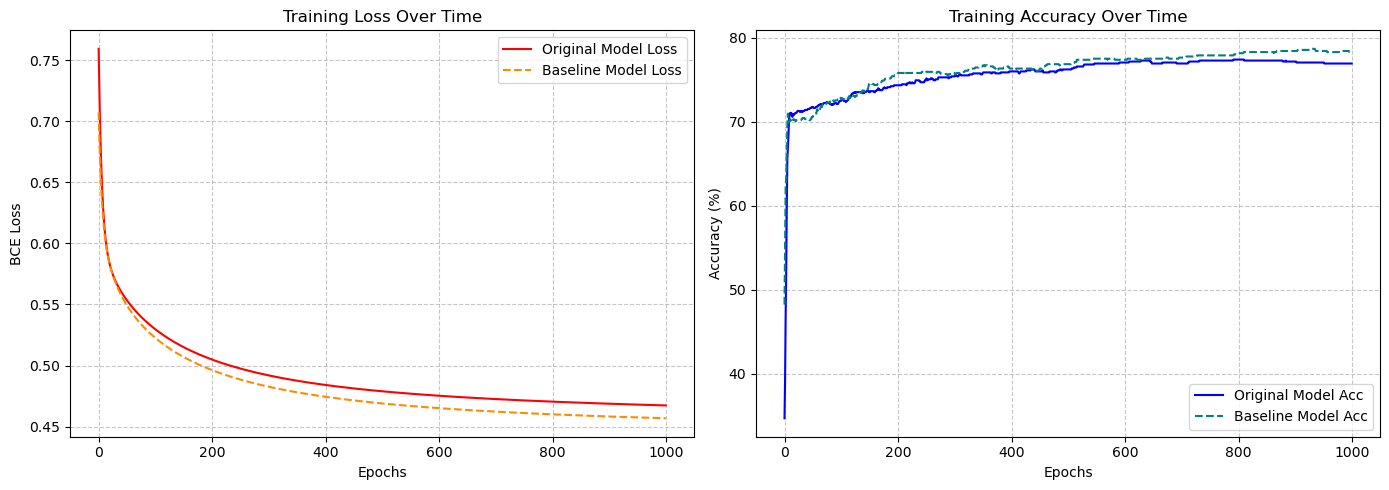


--- Phase 6: Model Evaluation ---

--- Accuracy (Train / Test) ---
1. Original Model: Train 76.9% | Test 81.3%
2. Forget Model:   Train 77.4% | Test 79.3%
3. Baseline Model: Train 78.3% | Test 79.3%  <-- (Train evaluated on pure retain set)

--- Membership Inference Attack (MIA) Score ---
1. Original Model: 52.9%
2. Forget Model:   52.4%
3. Baseline Model: 55.9%


In [3]:
# ==========================================
# Phase 1: Dual-Scaler Data Pipeline
# ==========================================
print("--- Phase 1: Splitting Data & Applying Dual Scalers ---")

numerical_cols = [
    'Duration_in_month', 'Credit_amount', 
    'Installment_rate_in_percentage_of_disposable_income',
    'Present_residence_since', 'Age_in_years',
    'Number_of_existing_credits_at_this_bank',
    'Number_of_people_being_liable_to_provide_maintenance_for'
]

# 1. Base Splits (DataFrames)
df_train_full, df_test, y_train_full_df, y_test_df = train_test_split(
    df_encoded, y, test_size=0.15, random_state=42
)
df_retain, df_forget, y_retain_df, y_forget_df = train_test_split(
    df_train_full, y_train_full_df, test_size=0.10, random_state=42
)

def to_tensor(df_x, df_y):
    X = torch.tensor(df_x.astype(float).values, dtype=torch.float32)
    label = torch.tensor(df_y.astype(float).values, dtype=torch.float32).view(-1, 1)
    return X, label

# ---------------------------------------------------------
# UNIVERSE A: The Full Dataset (For Original & Forget Models)
# ---------------------------------------------------------
df_train_A = df_train_full.copy()
df_forget_A = df_forget.copy()
df_test_A = df_test.copy()

scaler_full = StandardScaler()
scaler_full.fit(df_train_A[numerical_cols])

df_train_A[numerical_cols] = scaler_full.transform(df_train_A[numerical_cols])
df_forget_A[numerical_cols] = scaler_full.transform(df_forget_A[numerical_cols])
df_test_A[numerical_cols] = scaler_full.transform(df_test_A[numerical_cols])

X_train_full, y_train_full = to_tensor(df_train_A, y_train_full_df)
X_forget_full, y_forget_full = to_tensor(df_forget_A, y_forget_df)
X_test_full, y_test_full = to_tensor(df_test_A, y_test_df)

# ---------------------------------------------------------
# UNIVERSE B: The Pure Deletion (For Baseline Model)
# ---------------------------------------------------------
df_retain_B = df_retain.copy()
df_forget_B = df_forget.copy()
df_test_B = df_test.copy()

scaler_retain = StandardScaler()
scaler_retain.fit(df_retain_B[numerical_cols])

df_retain_B[numerical_cols] = scaler_retain.transform(df_retain_B[numerical_cols])
df_forget_B[numerical_cols] = scaler_retain.transform(df_forget_B[numerical_cols])
df_test_B[numerical_cols] = scaler_retain.transform(df_test_B[numerical_cols])

X_retain_pure, y_retain_pure = to_tensor(df_retain_B, y_retain_df)
X_forget_pure, y_forget_pure = to_tensor(df_forget_B, y_forget_df)
X_test_pure, y_test_pure = to_tensor(df_test_B, y_test_df)

input_dim = X_train_full.shape[1]

# ==========================================
# Model Architecture & Hyperparameters
# ==========================================
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x)

weight_decay_lambda = 0.0001
learning_rate = 0.05
epochs = 1000
criterion = nn.BCEWithLogitsLoss()

# ==========================================
# Phase 2: ORIGINAL MODEL
# ==========================================
print("\n--- Phase 2: Training Original Model ---")
original_model = LogisticRegression(input_dim)
orig_optimizer = optim.SGD(original_model.parameters(), lr=learning_rate, weight_decay=weight_decay_lambda)

orig_train_losses = []
orig_train_accuracies = []

original_model.train()
for epoch in range(epochs):
    orig_optimizer.zero_grad()
    logits = original_model(X_train_full)
    loss = criterion(logits, y_train_full)
    loss.backward()
    orig_optimizer.step()
    
    orig_train_losses.append(loss.item())
    
    with torch.no_grad():
        preds = (logits > 0).float()
        acc = (preds == y_train_full).float().mean().item() * 100
        orig_train_accuracies.append(acc)
        
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {loss.item():.4f} | Accuracy: {acc:.1f}%")

# ==========================================
# Phase 3 & 4: FORGET MODEL
# ==========================================
print("\n--- Phase 3 & 4: Building Forget Model (Unlearning) ---")
original_model.eval() 
original_model.zero_grad() 

forget_loss = criterion(original_model(X_forget_full), y_forget_full)
forget_loss.backward()

nabla_f = []
for param in original_model.parameters():
    total_grad = param.grad + (weight_decay_lambda * param.data)
    nabla_f.append(total_grad.detach().clone())

v_param = {name: nn.Parameter(torch.zeros_like(param)) for name, param in original_model.named_parameters()}
v_optimizer = optim.SGD(v_param.values(), lr=0.01)

def l2_regularization(params):
    return sum(p.norm(2)**2 for p in params) / 2

def gradient_vector_inner_product(grads, vector_values):
    return sum(torch.sum(g * v) for g, v in zip(grads, vector_values))

def jvp_norm_loss(arch, primals, tangents, inp):
    dual_params = {}
    with fwAD.dual_level():
        for name, p in primals.items():
            dual_params[name] = fwAD.make_dual(p, tangents[name])
        out = functional_call(arch, dual_params, inp)
        jvp = fwAD.unpack_dual(out).tangent
    return (torch.norm(jvp) ** 2) / inp.shape[0]

for epoch in range(150):
    if (epoch + 1) in [30, 60, 90, 120]:
        v_optimizer.param_groups[0]['lr'] *= 0.5
    v_optimizer.zero_grad()
    primals = dict(original_model.named_parameters())
    jvp_loss = 0.5 * jvp_norm_loss(original_model, primals, v_param, X_forget_full)
    inner_product_loss = gradient_vector_inner_product(nabla_f, v_param.values())
    reg_loss = 0.5 * weight_decay_lambda * l2_regularization(v_param.values())
    
    loss = jvp_loss + reg_loss - inner_product_loss
    loss.backward()
    v_optimizer.step()

forget_model = LogisticRegression(input_dim)
forget_model.load_state_dict(original_model.state_dict())
with torch.no_grad():
    for (name, param), v_step in zip(forget_model.named_parameters(), v_param.values()):
        param.copy_(param + v_step)
print("Forget Model generated.")

# ==========================================
# Phase 5: BASELINE COMPARISON MODEL
# ==========================================
print("\n--- Phase 5: Training Baseline Comparison Model (Pure Retrain) ---")
baseline_model = LogisticRegression(input_dim)
base_optimizer = optim.SGD(baseline_model.parameters(), lr=learning_rate, weight_decay=weight_decay_lambda)

base_train_losses = []
base_train_accuracies = []

baseline_model.train()
for epoch in range(epochs):
    base_optimizer.zero_grad()
    logits = baseline_model(X_retain_pure)
    loss = criterion(logits, y_retain_pure)
    loss.backward()
    base_optimizer.step()
    
    base_train_losses.append(loss.item())
    
    with torch.no_grad():
        preds = (logits > 0).float()
        acc = (preds == y_retain_pure).float().mean().item() * 100
        base_train_accuracies.append(acc)
        
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {loss.item():.4f} | Accuracy: {acc:.1f}%")

# ==========================================
# Phase 5.5: PLOT LEARNING CURVES
# ==========================================
plt.figure(figsize=(14, 5))

# Plot 1: Losses
plt.subplot(1, 2, 1)
plt.plot(orig_train_losses, color='red', label='Original Model Loss')
plt.plot(base_train_losses, color='darkorange', linestyle='--', label='Baseline Model Loss')
plt.title('Training Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 2: Accuracies
plt.subplot(1, 2, 2)
plt.plot(orig_train_accuracies, color='blue', label='Original Model Acc')
plt.plot(base_train_accuracies, color='teal', linestyle='--', label='Baseline Model Acc')
plt.title('Training Accuracy Over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# Phase 6: EVALUATION
# ==========================================
print("\n--- Phase 6: Model Evaluation ---")

def calculate_mia_score(eval_model, forget_x, forget_y, test_x, test_y):
    eval_model.eval()
    with torch.no_grad():
        bce_no_reduce = nn.BCEWithLogitsLoss(reduction='none')
        forget_losses = bce_no_reduce(eval_model(forget_x), forget_y).numpy()
        test_losses = bce_no_reduce(eval_model(test_x), test_y).numpy()

    min_len = min(len(forget_losses), len(test_losses))
    forget_losses = forget_losses[:min_len]
    test_losses = test_losses[:min_len]
    X_attack = np.concatenate([forget_losses, test_losses]).reshape(-1, 1)
    y_attack = np.concatenate([np.ones(min_len), np.zeros(min_len)])

    attacker = SklearnLR()
    attacker.fit(X_attack, y_attack)
    return accuracy_score(y_attack, attacker.predict(X_attack)) * 100

def calculate_accuracy(eval_model, X, y):
    eval_model.eval()
    with torch.no_grad():
        predictions = (eval_model(X) > 0).float()
        return (predictions == y).float().mean().item() * 100

# 1. Original Model (Evaluated in Universe A)
orig_train_acc = calculate_accuracy(original_model, X_train_full, y_train_full)
orig_test_acc = calculate_accuracy(original_model, X_test_full, y_test_full)
orig_mia = calculate_mia_score(original_model, X_forget_full, y_forget_full, X_test_full, y_test_full)

# 2. Forget Model (Evaluated in Universe A)
forget_train_acc = calculate_accuracy(forget_model, X_train_full, y_train_full)
forget_test_acc = calculate_accuracy(forget_model, X_test_full, y_test_full)
forget_mia = calculate_mia_score(forget_model, X_forget_full, y_forget_full, X_test_full, y_test_full)

# 3. Baseline Model (Evaluated in Universe B - Training acc is on retain set only)
base_train_acc = calculate_accuracy(baseline_model, X_retain_pure, y_retain_pure)
base_test_acc = calculate_accuracy(baseline_model, X_test_pure, y_test_pure)
base_mia = calculate_mia_score(baseline_model, X_forget_pure, y_forget_pure, X_test_pure, y_test_pure)

print("\n--- Accuracy (Train / Test) ---")
print(f"1. Original Model: Train {orig_train_acc:.1f}% | Test {orig_test_acc:.1f}%")
print(f"2. Forget Model:   Train {forget_train_acc:.1f}% | Test {forget_test_acc:.1f}%")
print(f"3. Baseline Model: Train {base_train_acc:.1f}% | Test {base_test_acc:.1f}%  <-- (Train evaluated on pure retain set)")

print("\n--- Membership Inference Attack (MIA) Score ---")
print(f"1. Original Model: {orig_mia:.1f}%")
print(f"2. Forget Model:   {forget_mia:.1f}%")
print(f"3. Baseline Model: {base_mia:.1f}%")

In [12]:
df_encoded.columns

Index(['Duration_in_month', 'Credit_amount',
       'Installment_rate_in_percentage_of_disposable_income',
       'Present_residence_since', 'Age_in_years',
       'Number_of_existing_credits_at_this_bank',
       'Number_of_people_being_liable_to_provide_maintenance_for',
       'Status_of_existing_checking_account_A11',
       'Status_of_existing_checking_account_A12',
       'Status_of_existing_checking_account_A13',
       'Status_of_existing_checking_account_A14', 'Credit_history_A30',
       'Credit_history_A31', 'Credit_history_A32', 'Credit_history_A33',
       'Credit_history_A34', 'Purpose_A40', 'Purpose_A41', 'Purpose_A410',
       'Purpose_A42', 'Purpose_A43', 'Purpose_A44', 'Purpose_A45',
       'Purpose_A46', 'Purpose_A48', 'Purpose_A49',
       'Savings_account_bonds_A61', 'Savings_account_bonds_A62',
       'Savings_account_bonds_A63', 'Savings_account_bonds_A64',
       'Savings_account_bonds_A65', 'Present_employment_since_A71',
       'Present_employment_since_A72', 

NameError: name 'mia_before' is not defined

In [29]:
type(y['class'][0])

numpy.float64